# F1 Strategy Predictor
## Real-Time Pit Stop & Compound Prediction

---
This notebook trains two models for real-time F1 race strategy prediction:
   1. PIT MODEL: Predicts if a driver will pit within the next 3 laps (binary)
   2. COMPOUND MODEL: Predicts which tire compound will be used next (multiclass)


### What changed from the LSTM version

| | LSTM | **This version** |
|---|---|---|
| Grouping | `(Year, Round, Driver, Stint)` | `(Year, Round, Driver)` — full race |
| Samples per race | N−1 (per driver) | **1 — the whole race at once** (per driver) |
| Architechture | `LSTM` based | `Transformer` based |
| Recurrence | LSTM processes laps sequentially | **Self-attention over all past laps** |
| Normalization | BatchNorm (RNN) | **LayerNorm (Transformer)** |

### Requirements
- `label_encoder.pkl` (from DataAnalysis.ipynb)
- `f1_dataset_clean.pkl` (from DataAnalysis.ipynb)

# 1. Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
if not hasattr(np, "NaN"):
    np.NaN = np.nan
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [3]:
# File I/O and serialization libraries
import joblib
import json
import os
from io import BytesIO

os.makedirs('Model', exist_ok=True)
os.makedirs('Other', exist_ok=True)

In [4]:
# FastF1: libreria open-source per dati F1 (telemetria, tempi, meteo)
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

In [5]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             f1_score, roc_auc_score,
                             precision_recall_curve)

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0
GPU available: []


In [7]:
urlDB = "https://raw.githubusercontent.com/FedericoSabbadini/f1-strategy-predictor/main/02_dbAnalysis/output/f1_dataset_clean.pkl"
urlENC = "https://raw.githubusercontent.com/FedericoSabbadini/f1-strategy-predictor/main/02_dbAnalysis/output/label_encoder.pkl"

# 2. Load Dataset

In [8]:
df_f1 = pd.read_pickle(urlDB)
print(f"Dataset loaded: {len(df_f1):,} rows, {df_f1.shape[1]} columns")

AttributeError: `np.NaN` was removed in the NumPy 2.0 release. Use `np.nan` instead.

In [ ]:
def download_bytes(url):
    """Downloads content from a given URL as bytes."""
    response = requests.get(url)
    response.raise_for_status()
    return response.content

# Load the pre-fitted LabelEncoder from DataAnalysis notebook
label_encoder = joblib.load(BytesIO(download_bytes(urlENC)))
print(f"Compound classes: {list(label_encoder.classes_)}")

Compound classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']


# 3. Define Features

In [ ]:
TARGETS   = ['PitIn3Laps', 'NextCompoundEnc']
META_COLS = ['Driver', 'Team', 'Circuit', 'Time', 'RaceName', 'Compound']

FEATURES = [col for col in df_f1.columns if col not in TARGETS + META_COLS]
n_feat = len(FEATURES)

print(f"Number of features: {n_feat}")
print(f"Features: {FEATURES}")

Number of features: 103
Features: ['LapNumber', 'Stint', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'TyreLife', 'FreshTyre', 'Position', 'Year', 'Round', 'AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'Rainfall', 'GapToLeader', 'StintProgress', 'LapTimeSec', 'LapStartTimeSec', 'Sector1TimeSec', 'Sector1SessionTimeSec', 'Sector2SessionTimeSec', 'Sector3SessionTimeSec', 'Sector2TimeSec', 'Sector3TimeSec', 'UnderCaution', 'IsPitLap', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'UndercutPotential', 'OvercutPotential', 'Circuit_Austin', 'Circuit_Baku', 'Circuit_Barcelona', 'Circuit_Budapest', 'Circuit_Imola', 'Circuit_Jeddah', 'Circuit_Las Vegas', 'Circuit_Le Castellet', 'Circuit_Lusail', 'Circuit_Marina Bay', 'Circuit_Melbourne', 'Circuit_Mexico City', 'Circuit_Miami', 'Circuit_Miami Gardens', 'Circuit_Monaco', 'Circuit_Montréal', 'Circuit_Monza', 'Circuit_Sakhir', 'Circuit_Shanghai', 'Circuit_Silverstone', 'Circuit_Spa-Fra

# 4. Data Preprocessing

### 4.1 Create Race Sequences for Transformer

**LSTM version** grouped by `(Year, Round, Driver, Stint)` and built N−1 samples
per stint — one per lap — each being a fixed 10-lap window padded with zeros
at the start. Causal safety was enforced by truncating the input.

**This version** groups by `(Year, Round, Driver)` and builds exactly **one sample
per race per driver**: the full race as a single sequence. Each label sequence
has one entry per lap. Causal safety is enforced by the lower-triangular
attention mask inside the Transformer — teacher forcing

In [ ]:
# LSTM used: SEQUENCE_LENGTH = 10 (fixed window)
# Here we use the full race length, capped at MAX_SEQ_LEN
MAX_SEQ_LEN = int(df_f1.groupby(['Year', 'Round', 'Driver'])['LapNumber'].max().max())

print(f"Maximum sequence length: {MAX_SEQ_LEN}")

Maximum sequence length: 78


In [ ]:
def create_race_sequences(df, target_col, features=FEATURES):
    """
    One sequence per driver per race (full race, not a sliding window).

    LSTM version: groupby Stint, N-1 samples of shape (10, n_features) each.
    This version: groupby Race, 1 sample of shape (race_len, n_features).

    X[i] : shape (race_len, n_features) — all laps in the race
    y[i] : shape (race_len,)            — one label per lap

    Real-time safety is guaranteed by the causal mask in the Transformer,
    not by truncating the input here.
    """
    X, y = [], []

    for (_, _, _), group in df.groupby(['Year', 'Round', 'Driver']):
        group = group.sort_values('LapNumber').reset_index(drop=True)

        X.append(group[features].values.astype(np.float32))
        y.append(group[target_col].values)

    return X, y

### 4.2 Temporal Train / Val / Test Split

Identical to the LSTM version: split by RaceID in chronological order.
70% train / 15% validation / 15% test.

In [ ]:
df_clean = df_f1.sort_values(['Year', 'Round', 'LapNumber']).reset_index(drop=True)

# Create unique RaceID for each race (e.g., "2023_05" for round 5 of 2023)
df_clean['RaceID'] = df_clean['Year'].astype(str) + '_' + df_clean['Round'].astype(str).str.zfill(2)
# str.zfill(2) pads round number with zeros (5 -> "05") for correct sorting

In [ ]:
# Split races into train/val/test sets (70%/15%/15%)
SPLIT_PERC= [0.70, 0.85]
races = sorted(df_clean['RaceID'].unique())
n = len(races)

df_train = df_clean[df_clean['RaceID'].isin(races[:int(SPLIT_PERC[0]*n)])].copy()
df_val = df_clean[df_clean['RaceID'].isin(races[int(SPLIT_PERC[0]*n):int(SPLIT_PERC[1]*n)])].copy()
df_test = df_clean[df_clean['RaceID'].isin(races[int(SPLIT_PERC[1]*n):])].copy()

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 60,742 | Val: 12,622 | Test: 13,393


In [ ]:
X_pit_train_raw,  y_pit_train_raw  = create_race_sequences(df_train, 'PitIn3Laps')
X_pit_val_raw,    y_pit_val_raw    = create_race_sequences(df_val,   'PitIn3Laps')
X_pit_test_raw,   y_pit_test_raw   = create_race_sequences(df_test,  'PitIn3Laps')

X_comp_train_raw, y_comp_train_raw = create_race_sequences(df_train, 'NextCompoundEnc')
X_comp_val_raw,   y_comp_val_raw   = create_race_sequences(df_val,   'NextCompoundEnc')
X_comp_test_raw,  y_comp_test_raw  = create_race_sequences(df_test,  'NextCompoundEnc')


lengths = [len(x) for x in X_pit_train_raw]
print(f"Races in train set: {len(X_pit_train_raw):,}")
print(f"Race length — Min: {min(lengths)} | Max: {max(lengths)} | Mean: {np.mean(lengths):.1f}")

Races in train set: 1,240
Race length — Min: 1 | Max: 76 | Mean: 49.0


### 4.3 Normalizzazione

Same RobustScaler as the LSTM version — robust to outliers like safety car and pit laps.

The only difference is how we fit it: the LSTM version reshaped a 3D array to 2D to correcty working with temporal sequences. Here we don't need to trasform, but vstack the variable-length sequences into a flat matrix (to scale them).

In [ ]:
scaler_pit  = RobustScaler()
scaler_comp = RobustScaler()

def fit_scaler(sequences, scaler):
    # LSTM version: scaler.fit_transform(X.reshape(-1, n_feat)).reshape(X.shape)
    # Here: vstack variable-length sequences -> same result, different shape input
    scaler.fit(np.vstack(sequences))

def scale_sequences(sequences, scaler):
    scaled = []
    for s in sequences:
        t = scaler.transform(s)
        t[~np.isfinite(t)] = 0.0       # These can occur from division by zero during scaling
        scaled.append(t.astype(np.float32))
    return scaled

fit_scaler(X_pit_train_raw,  scaler_pit)
fit_scaler(X_comp_train_raw, scaler_comp)

In [ ]:
X_pit_train_raw  = scale_sequences(X_pit_train_raw,  scaler_pit)
X_pit_val_raw    = scale_sequences(X_pit_val_raw,    scaler_pit)
X_pit_test_raw   = scale_sequences(X_pit_test_raw,   scaler_pit)

X_comp_train_raw = scale_sequences(X_comp_train_raw, scaler_comp)
X_comp_val_raw   = scale_sequences(X_comp_val_raw,   scaler_comp)
X_comp_test_raw  = scale_sequences(X_comp_test_raw,  scaler_comp)

### 4.4 Padding

We require fixed-length batches, so we pad both X and y to MAX_SEQ_LEN.

- **X** is padded with 0.0 at the end (post-padding) — real laps at the start,
zeros at the end. Positional encoding is consistent: lap 1 is always position 0.

- **y** is padded with −1 — an impossible label value used by the masked loss
to identify and ignore padded positions during training.

In [ ]:
def pad_race_sequences(X_list, y_list, max_len, n_features=n_feat):
    """
    Post-pad X and y to max_len.

    LSTM version: no label padding needed (fixed-length sequences, scalar labels).
    This version: both X and y must be padded to the same length.

    Returns
    -------
    X    : ndarray (N, max_len, n_features)
    y    : ndarray (N, max_len)             — integer labels, -1 where padded
    mask : ndarray (N, max_len) bool        — True = real lap, tracciamento giri falsati
    """
    N    = len(X_list)

    X    = np.zeros((N, max_len, n_features), dtype=np.float32)
    y    = np.full( (N, max_len), -1,         dtype=np.int32)
    mask = np.zeros((N, max_len),             dtype=bool)

    for i, (x_seq, y_seq) in enumerate(zip(X_list, y_list)):
        sLen = len(x_seq)
        X[i, :sLen]   = x_seq # X[i] = [ real data(6) | 0 0 0 0 ]
        y[i, :sLen]   = y_seq # y[i] = [ real data(6) | 0 0 0 0 ]
        mask[i, :sLen] = True # mask[i] = [ TRUE(6) | 0 0 0 0 ]

    return X, y, mask

In [ ]:
X_pit_train,  y_pit_train,  mask_pit_train  = pad_race_sequences(X_pit_train_raw,  y_pit_train_raw,  MAX_SEQ_LEN)
X_pit_val,    y_pit_val,    mask_pit_val    = pad_race_sequences(X_pit_val_raw,    y_pit_val_raw,    MAX_SEQ_LEN)
X_pit_test,   y_pit_test,   mask_pit_test   = pad_race_sequences(X_pit_test_raw,   y_pit_test_raw,   MAX_SEQ_LEN)

X_comp_train, y_comp_train, mask_comp_train = pad_race_sequences(X_comp_train_raw, y_comp_train_raw, MAX_SEQ_LEN)
X_comp_val,   y_comp_val,   mask_comp_val   = pad_race_sequences(X_comp_val_raw,   y_comp_val_raw,   MAX_SEQ_LEN)
X_comp_test,  y_comp_test,  mask_comp_test  = pad_race_sequences(X_comp_test_raw,  y_comp_test_raw,  MAX_SEQ_LEN)

# 5. Architecture

Building blocks are unchanged from the previous Transformer version.
The only modification to the model functions is the removal of
`GlobalAveragePooling1D` — the sequence dimension is preserved so the
model outputs one prediction per lap instead of one per race.

## 5.1. Preliminar Definitions

### 5.1.1. Positional Encoding

In [ ]:
class SinusoidalPositionalEncoding(tf.keras.layers.Layer):
    """
    Adds sinusoidal positional encodings (Vaswani et al. 2017).

    LSTM equivalent: none — order was implicit in the recurrent connections.
    Here: explicit encoding so the Transformer knows which lap is which.
    """

    def __init__(self, max_len=200, **kwargs): #constr
        super().__init__(**kwargs)
        self.max_len = max_len

    def call(self, x):
        seq_len = tf.shape(x)[1] # laps
        d_model = tf.shape(x)[2] # vector size

        positions = tf.cast(tf.range(self.max_len)[:, tf.newaxis], tf.float32) # column vector
        dims      = tf.cast(tf.range(d_model)[tf.newaxis, :],      tf.float32) # row vector
        # Formula from Vaswani et al., 2017
        angles    = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))
        sin_enc = tf.math.sin(angles[:, 0::2])
        cos_enc = tf.math.cos(angles[:, 1::2])

        # apply to vectors
        pe = tf.reshape(tf.stack([sin_enc, cos_enc], axis=-1), [self.max_len, -1])[:, :d_model]

        return x + tf.cast(pe[tf.newaxis, :seq_len, :], x.dtype) # Add positional encoding to input

    def get_config(self): #getter
        cfg = super().get_config()
        cfg.update({'max_len': self.max_len})
        return cfg

### 5.1.2. Transformer

My design is different from the classical Transformer used by NLP. Indeed I don't need a decoder part  but only an encoder's for predictions (not generative). I have decided to use:
- Based on Transformer's Encoder: MultiHead Attention + Add/Norm + FFN + + Add/Norm
- Working with Causal Masking (autoregressive, GPT/language modeling-typical) + Softmax
- Using Positional Encoding to mantain positional laps informations
- The original 2017 PostLayerNorm Transformer order is known to be less stable. The versions used is Pre-LN (normalise the input before the sub-layer), which is the modern standard.

In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    """
    The causal mask (lower-triangular) is the key component that replaces
    input truncation: position i attends only to positions 0..i, so no
    future lap is ever visible — real-time safe by architecture.
    """

    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0 #size constraint

        self.attn = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        # GELU replaces ReLU used in LSTM dense layers — smoother, better for Transformers
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='gelu', kernel_regularizer=l2(1e-4)),
            Dropout(dropout),
            Dense(d_model, kernel_regularizer=l2(1e-4)),
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = Dropout(dropout)
        self.drop2 = Dropout(dropout)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1] # laps

        # Lower-triangular causal mask — replaces input truncation
        causal_mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len), dtype=tf.bool), -1, 0
        ) # No need to convert False to -inf. The layer handles it internally.

        # Norm
        x_norm = self.norm1(x)
        # SelfAttention
        z = self.attn(query=x_norm, value=x_norm, key=x_norm,
                            attention_mask=causal_mask, training=training)
        # Add
        x = x + self.drop1(z, training=training)

        # Norm
        x_norm = self.norm2(x)
        # FFN
        ffn_out = self.ffn(x_norm, training=training)
        # Add
        x = x + self.drop2(ffn_out, training=training)

        return x   # shape preserved: (batch, seq_len, d_model)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'num_heads': self.attn._num_heads,
            'dropout':   self.drop1.rate,
        })
        return cfg

### 5.1.3. Loss
NEW vs LSTM version — required because y is padded with -1.
- The model output is (batch, seq_len, 1/n_classes) — one prediction per lap.
- y_true is (batch, seq_len) — one label per lap, -1 where padded.
We must zero out the loss contribution of padded positions!!.

In [ ]:
def masked_binary_crossentropy(y_true, y_pred):
    """
    Binary cross-entropy + ignoring positions where y_true == -1.

    y_true : (batch, seq_len)    — 0/1 labels, -1 for padded positions
    y_pred : (batch, seq_len)    — sigmoid probabilities
    """
    mask     = tf.cast(tf.not_equal(y_true, -1), tf.float32) # mask is 1 where data is real, 0 where padded
    y_safe   = tf.cast(
        tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true),
        tf.float32
    )

    bce = tf.keras.losses.binary_crossentropy(
        tf.expand_dims(y_safe, -1),
        tf.expand_dims(y_pred, -1)
    )   # (batch, seq_len)

    return tf.reduce_sum(bce * mask) / (tf.reduce_sum(mask) + 1e-8)

In [ ]:
def masked_categorical_crossentropy(y_true, y_pred):
    """
    Sparse categorical cross-entropy ignoring positions where y_true == -1.

    y_true : (batch, seq_len)            — class indices, -1 for padded
    y_pred : (batch, seq_len, n_classes) — softmax probabilities
    """
    mask   = tf.cast(tf.not_equal(y_true, -1), tf.float32)
    y_safe = tf.cast(
        tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true),
    tf.float32
    )

    sce = tf.keras.losses.sparse_categorical_crossentropy(y_safe, y_pred) # (batch, seq_len)

    return tf.reduce_sum(sce * mask) / (tf.reduce_sum(mask) + 1e-8)

## 5.2. Models

### 5.2.1. PIT Model

In [ ]:
def build_pit_transformer(
    max_len    = MAX_SEQ_LEN, #maximum number of laps
    n_features = n_feat, #number of input features per lap
    d_model    = 96, #internal vector size
    num_heads  = 4, #parallel attention heads  --> d_model%num_heads == 0
    ff_dim     = 288, #internal width of the feed-forward network --> ff_dim = 4*d_model
    num_blocks = 3, #TransformerBlocks stacked
    dropout    = 0.4,
):

    inputs = Input(shape=(max_len, n_features), name='input')

    x = Dense(d_model, name='input_projection')(inputs) # on n_features=64

    x = SinusoidalPositionalEncoding(max_len=max_len, name='pos_enc')(x) # on max_len=85

    x = Dropout(dropout, name='input_dropout')(x)
    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout,
                             name=f'transformer_block_{i}')(x)

    x = LayerNormalization(epsilon=1e-6, name='pre_head_norm')(x)
    x = Dense(32, activation='gelu', kernel_regularizer=l2(0.001), name='head_dense')(x)

    x = Dropout(dropout, name='head_dropout')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, output, name='transformer_pit_seq2seq')


    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=0.003326,
            weight_decay=2.762e-5,
            clipnorm=1.0
        ),
        loss=masked_binary_crossentropy,
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model


model_pit = build_pit_transformer()
model_pit.summary()

Model: "transformer_pit_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 78, 103)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 78, 96)         │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc                         │ (None, 78, 96)         │             0 │
│ (SinusoidalPositionalEncoding)  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dropout (Dropout)         │ (None, 78, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 78, 96)         │        93,312 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 78, 96)         │        93,312 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 78, 96)         │        93,312 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_head_norm                   │ (None, 78, 96)         │           192 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 78, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 78, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 78, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293,249 (1.12 MB)

 Trainable params: 293,249 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2.2. Compound Model

In [ ]:
def build_compound_transformer(
    max_len    = MAX_SEQ_LEN,
    n_features = n_feat,
    n_classes  = 4,
    d_model    = 128,
    num_heads  = 4, #d_model%num_heads == 0
    ff_dim     = 384, #internal width of the feed-forward network --> ff_dim = 4*d_model
    num_blocks = 4,
    dropout    = 0.4,
):


    inputs = Input(shape=(max_len, n_features), name='input')

    x = Dense(d_model, name='input_projection')(inputs)

    x = SinusoidalPositionalEncoding(max_len=max_len, name='pos_enc')(x) # on max_len=85

    x = Dropout(dropout, name='input_dropout')(x)
    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_dim, dropout,
                             name=f'transformer_block_{i}')(x)

    x = LayerNormalization(epsilon=1e-6, name='pre_head_norm')(x)
    x = Dense(48, activation='gelu', kernel_regularizer=l2(0.01), name='head_dense_1')(x)

    x = Dropout(dropout,       name='head_dropout_1')(x)
    x = Dense(24, activation='gelu', kernel_regularizer=l2(0.01), name='head_dense_2')(x)

    x = Dropout(dropout * 0.5, name='head_dropout_2')(x)
    output = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs, output, name='transformer_compound_seq2seq')


    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=0.00019895,
            weight_decay=0.0001983,
            clipnorm=1.0
        ),
        loss=masked_categorical_crossentropy,
        metrics=['accuracy']
    )

    return model


model_comp = build_compound_transformer(n_classes=len(label_encoder.classes_))
model_comp.summary()

Model: "transformer_compound_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 78, 103)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 78, 128)        │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_enc                         │ (None, 78, 128)        │             0 │
│ (SinusoidalPositionalEncoding)  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dropout (Dropout)         │ (None, 78, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 78, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 78, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 78, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 78, 128)        │       165,376 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_head_norm                   │ (None, 78, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_1 (Dense)            │ (None, 78, 48)         │         6,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 78, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_2 (Dense)            │ (None, 78, 24)         │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 78, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 78, 4)          │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,540 (2.60 MB)

 Trainable params: 682,540 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Training

In [ ]:
cb_pit = [
    EarlyStopping(
        monitor='auc',
        patience=20,             
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        mode='min',
        verbose=1
    )
]

print("Training PIT Transformer (seq-to-seq)...")
print("=" * 60)

history_pit = model_pit.fit(
    X_pit_train, y_pit_train,
    validation_data=(X_pit_val, y_pit_val),
    epochs=50,
    batch_size=64,     
    callbacks=cb_pit,
    verbose=1
)

Training PIT Transformer (seq-to-seq)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - auc: 0.5834 - loss: 0.7241 - val_auc: 0.8156 - val_loss: 0.5965 - learning_rate: 0.0033
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - auc: 0.7501 - loss: 0.5976 - val_auc: 0.8346 - val_loss: 0.6048 - learning_rate: 0.0033
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.8119 - loss: 0.5422 - val_auc: 0.7920 - val_loss: 0.5978 - learning_rate: 0.0033
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.7954 - loss: 0.5028 - val_auc: 0.7959 - val_loss: 0.6046 - learning_rate: 0.0033
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.8126 - loss: 0.4703 - val_auc: 0.7558 - val_loss: 0.5784 - learning_rate: 0.0033
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.8093 - loss: 0.4459 - val_auc: 0.7508 - val_loss: 0.5670 - learning_rate: 0.0033
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8250 - loss: 0.4233 - val_auc: 0.7244 - val_loss: 0.54

In [ ]:
cb_comp = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=18,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.6,
        patience=8,
        mode='min',
        verbose=1
    )
]

print("\nTraining COMPOUND Transformer (seq-to-seq)...")
print("=" * 60)

history_comp = model_comp.fit(
    X_comp_train, y_comp_train,
    validation_data=(X_comp_val, y_comp_val),
    epochs=50,
    batch_size=64,
    callbacks=cb_comp,
    verbose=1
)


Training COMPOUND Transformer (seq-to-seq)...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.2125 - loss: 2.7159 - val_accuracy: 0.3392 - val_loss: 2.2268 - learning_rate: 1.9895e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3026 - loss: 2.3472 - val_accuracy: 0.3397 - val_loss: 2.1338 - learning_rate: 1.9895e-04
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3181 - loss: 2.2453 - val_accuracy: 0.3424 - val_loss: 2.0688 - learning_rate: 1.9895e-04
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3284 - loss: 2.1692 - val_accuracy: 0.3435 - val_loss: 2.0313 - learning_rate: 1.9895e-04
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3386 - loss: 2.0965 - val_accuracy: 0.3425 - val_loss: 1.9981 - learning_rate: 1.9895e-04
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3490 - loss: 2.0282 - val_accuracy: 0.3436 - val_loss: 1.9716 - learning_rate: 1.9895e-04
Epoch 7/50
20/20 ━━━━━━━

# 7. Evaluation

The model outputs `(N_races, MAX_SEQ_LEN, ...)`.
We use the boolean mask to extract only real-lap predictions before computing
metrics — equivalent to what the LSTM version computed on its flat samples.

In [ ]:
print("-" * 50)
print("PIT MODEL (PitIn3Laps)")
print("-" * 50)

# Output shape: (N_races, MAX_SEQ_LEN, 1)
pit_pred_full = model_pit.predict(X_pit_test, verbose=0)

# Flatten to real laps only — LSTM version had this shape directly
pit_pred_prob = pit_pred_full[mask_pit_test, 0]   # (total_real_laps,)
pit_true      = y_pit_test[mask_pit_test]          # (total_real_laps,)

prec, rec, thresh = precision_recall_curve(pit_true, pit_pred_prob)
f1_arr     = 2 * prec * rec / (prec + rec + 1e-8)
best_idx   = np.argmax(f1_arr)
opt_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

pit_pred = (pit_pred_prob > opt_thresh).astype(int)

pit_auc = roc_auc_score(pit_true, pit_pred_prob)
pit_f1  = f1_score(pit_true, pit_pred)
pit_acc = accuracy_score(pit_true, pit_pred)

print(f"AUC-ROC:   {pit_auc:.3f}")
print(f"F1 Score:  {pit_f1:.3f}")
print(f"Accuracy:  {pit_acc:.3f}")
print(f"Precision: {prec[best_idx]:.3f}")
print(f"Recall:    {rec[best_idx]:.3f}")
print(f"Threshold: {opt_thresh:.3f}")

cm_pit = confusion_matrix(pit_true, pit_pred)
print(f"\nConfusion Matrix:")
print(f"           Pred:0  Pred:1")
print(f"True:0     {cm_pit[0,0]:6d}  {cm_pit[0,1]:6d}")
print(f"True:1     {cm_pit[1,0]:6d}  {cm_pit[1,1]:6d}")

--------------------------------------------------
PIT MODEL (PitIn3Laps)
--------------------------------------------------
AUC-ROC:   0.854
F1 Score:  0.616
Accuracy:  0.882
Precision: 0.794
Recall:    0.504
Threshold: 0.903

Confusion Matrix:
           Pred:0  Pred:1
True:0      10545     329
True:1       1250    1269


In [ ]:
print("-" * 50)
print("COMPOUND MODEL (NextCompound)")
print("-" * 50)

# Output shape: (N_races, MAX_SEQ_LEN, n_classes)
comp_pred_full = model_comp.predict(X_comp_test, verbose=0)

comp_pred_prob = comp_pred_full[mask_comp_test]   # (total_real_laps, n_classes)
comp_pred      = comp_pred_prob.argmax(axis=1)
comp_true      = y_comp_test[mask_comp_test]

comp_acc = accuracy_score(comp_true, comp_pred)
comp_f1  = f1_score(comp_true, comp_pred, average='weighted')

print(f"Accuracy:      {comp_acc:.3f}")
print(f"F1 (weighted): {comp_f1:.3f}")

print("\nPer-class accuracy:")
for i, cls in enumerate(label_encoder.classes_):
    mask_cls       = comp_true == i
    cls_acc        = (comp_pred[mask_cls] == i).mean() if mask_cls.sum() > 0 else 0.0
    cls_pred_count = (comp_pred == i).sum()
    print(f"  {cls:12s}: {cls_acc:.3f}  (n={mask_cls.sum():,}, pred={cls_pred_count:,})")

cm_comp = confusion_matrix(comp_true, comp_pred)
print(f"\nConfusion Matrix (classes: {list(label_encoder.classes_)}):")
print(cm_comp)

--------------------------------------------------
COMPOUND MODEL (NextCompound)
--------------------------------------------------
Accuracy:      0.673
F1 (weighted): 0.659

Per-class accuracy:
  HARD        : 0.957  (n=5,689, pred=8,115)
  INTERMEDIATE: 0.792  (n=53, pred=547)
  MEDIUM      : 0.540  (n=4,753, pred=3,133)
  SOFT        : 0.331  (n=2,898, pred=1,598)

Confusion Matrix (classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']):
[[5447   52  174   16]
 [   0   42   11    0]
 [1175  390 2566  622]
 [1493   63  382  960]]


# 8. Training Curves

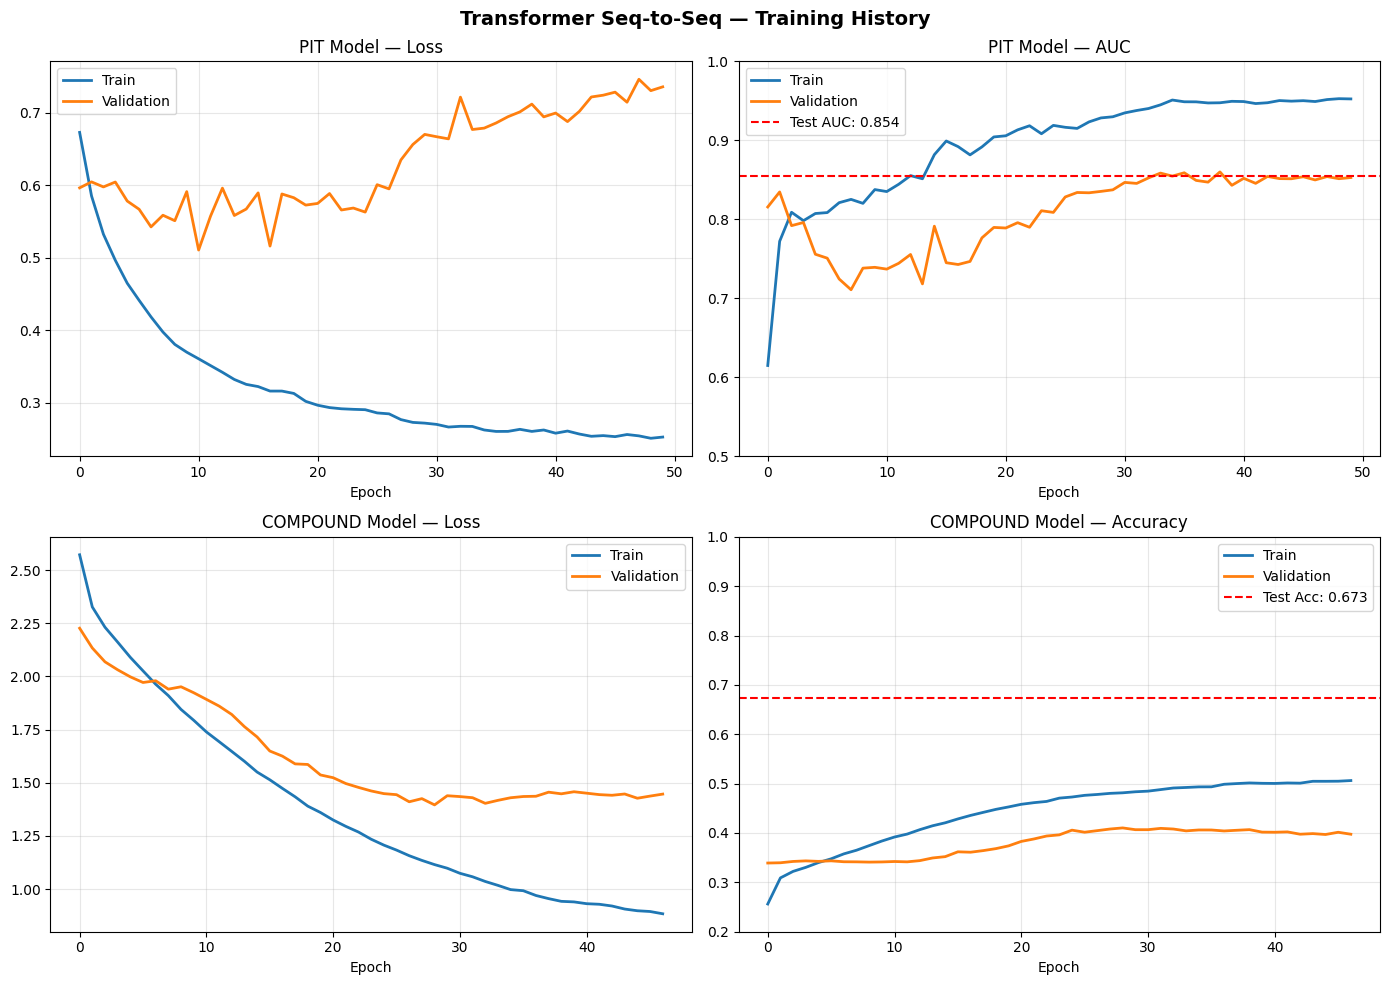

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transformer Seq-to-Seq — Training History', fontsize=14, fontweight='bold')

axes[0, 0].plot(history_pit.history['loss'],     label='Train', linewidth=2)
axes[0, 0].plot(history_pit.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('PIT Model — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_pit.history['auc'],     label='Train', linewidth=2)
axes[0, 1].plot(history_pit.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].axhline(y=pit_auc, color='r', linestyle='--', label=f'Test AUC: {pit_auc:.3f}')
axes[0, 1].set_title('PIT Model — AUC')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0.5, 1.0)

axes[1, 0].plot(history_comp.history['loss'],     label='Train', linewidth=2)
axes[1, 0].plot(history_comp.history['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('COMPOUND Model — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_comp.history['accuracy'],     label='Train', linewidth=2)
axes[1, 1].plot(history_comp.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axhline(y=comp_acc, color='r', linestyle='--', label=f'Test Acc: {comp_acc:.3f}')
axes[1, 1].set_title('COMPOUND Model — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0.2, 1.0)

plt.tight_layout()
plt.savefig('Other/transformer_seq2seq_history.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. Save

In [ ]:
model_pit.save('Model/f1_pit_transformer_seq2seq.keras')
model_comp.save('Model/f1_compound_transformer_seq2seq.keras')
print("Models saved.")

Models saved.


In [ ]:
joblib.dump(scaler_pit,    'Model/f1_pit_scaler.pkl')
joblib.dump(scaler_comp,   'Model/f1_comp_scaler.pkl')
joblib.dump(label_encoder, 'Model/label_encoder.pkl')
print("Scalers saved.")

Scalers saved.


In [ ]:
config = {
    'architecture'     : 'causal_transformer_seq2seq',
    'sequence_strategy': 'one_sequence_per_race',
    'max_seq_len'      : MAX_SEQ_LEN,
    'n_features'       : n_feat,
    'd_model'          : 64,
    'num_heads'        : 4,
    'ff_dim'           : 128,
    'num_blocks'       : 3,
    'FEATURES'         : FEATURES,
    'pit_threshold'    : float(opt_thresh),
    'compound_classes' : list(label_encoder.classes_),
    'metrics': {
        'pit_auc'          : float(pit_auc),
        'pit_f1'           : float(pit_f1),
        'pit_accuracy'     : float(pit_acc),
        'compound_accuracy': float(comp_acc),
        'compound_f1'      : float(comp_f1)
    }
}

with open('Model/transformerSeq2SeqConfig.json', 'w') as f:
    json.dump(config, f, indent=2)

df_f1.to_pickle('Model/f1_dataset_featured.pkl')
print("Config and dataset saved.")

Config and dataset saved.
